# Single Neuron with Different Activation Functions

**Unit:** Unit 4: Neural Networks Fundamentals

Every artificial neuron does the same two-step job: compute a weighted sum of its
inputs plus a bias, then pass that score through an **activation function**. Keras
lets you pick `sigmoid`, `tanh`, `relu`, and more — so which one should you choose,
and how much does the choice actually change what a neuron can learn? Instead of
memorizing rules of thumb, we run the experiment: we train the **same single neuron**
on the **same real 2D dataset** three times, changing only the activation, and compare
the accuracies and decision boundaries side by side.

## 📚 Learning Objectives

By completing this notebook, you will:
- Plot and compare the sigmoid, tanh, and ReLU activation curves
- Build a single-neuron model in Keras: `Dense(1)` with a chosen activation
- Train the same neuron with each activation on the same dataset (change one thing at a time)
- Compare accuracies and decision boundaries in one figure — and explain what the activation can and cannot change

## 🔗 Where this fits

**Builds on:** Unit 4, lesson 01 "Simple Perceptron" — the same single neuron, with its step function replaced by sigmoid, tanh and ReLU.

**Used later in:** Course 08 (AIAT 122) — Unit 1, where activation choice is studied against vanishing gradients.

---


## 🎯 The activation that was in the 2012 paper for a reason

When AlexNet won ImageNet 2012 with a top-5 error of 15.3% against the runner-up's
26.2%, its authors listed the ingredients that made it possible. The first one in
the paper is not the depth or the data — it is the **ReLU**. Krizhevsky, Sutskever
and Hinton report (their Figure 1) that a four-layer convolutional network with
ReLUs reached a given training-error level on CIFAR-10 **several times faster**
than the identical network with `tanh` units. Faster training meant they could
train a larger network on more data inside the time they had, and that is what the
eleven-point margin was made of.

The reason is visible in the curves you are about to plot. `sigmoid` and `tanh`
**saturate**: once the input is large in either direction, the curve flattens and
its slope goes to nearly zero, so the gradient that trains the weight underneath
it goes to nearly zero as well. ReLU does not saturate on the positive side — its
slope stays exactly 1 — so the signal keeps flowing. That is the whole argument,
and it is why almost every hidden layer in this diploma uses ReLU.

### What goes wrong from picking an activation by habit

Two opposite failures. Stack saturating activations deep and the gradient shrinks
by a factor at every layer until the early layers stop learning — the **vanishing
gradient** problem identified by Hochreiter in 1991. Use ReLU carelessly with too
large a learning rate and units get pushed into the negative region where their
gradient is exactly zero and can never come back — **dead ReLU**, which is exactly
what produced the 50% XOR failure in Unit 3, notebook 02. The experiment below
isolates the choice so you can see how much it does, and how much it does not.


## 1. The Three Classic Activations

The activation function decides how the neuron's raw score `z = w·x + b` becomes an output:

| Activation | Formula | Output range |
|---|---|---|
| Sigmoid | `1 / (1 + e^-z)` | (0, 1) |
| Tanh | `tanh(z)` | (-1, 1) |
| ReLU | `max(0, z)` | [0, ∞) |

Before training anything, let's look at their shapes. Notice that all three are
**monotonic**: as `z` grows, the output never decreases. Keep that in mind — it will
explain the decision boundaries we see later.

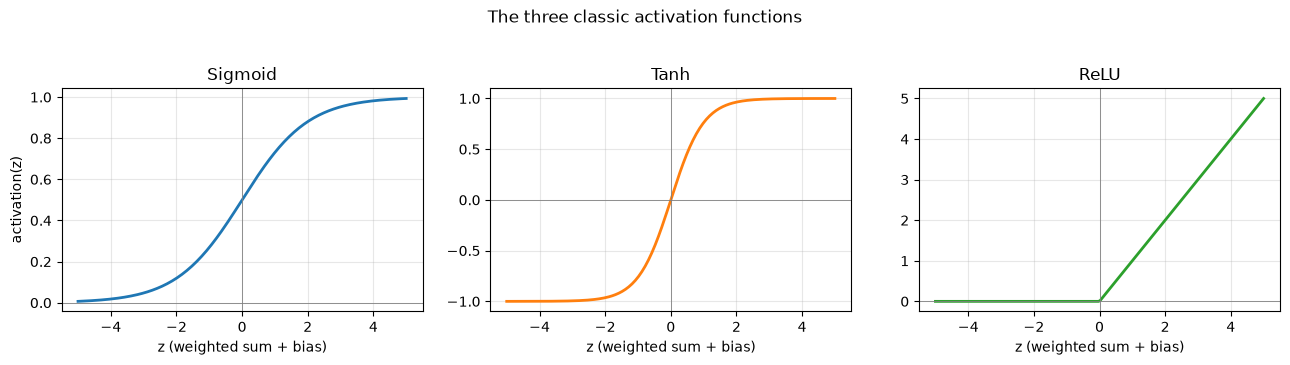

Output at a few sample scores:
     z |  sigmoid |    tanh |  relu
  -3.0 |    0.047 |  -0.995 |   0.0
  -1.0 |    0.269 |  -0.762 |   0.0
   0.0 |    0.500 |   0.000 |   0.0
   1.0 |    0.731 |   0.762 |   1.0
   3.0 |    0.953 |   0.995 |   3.0


In [1]:
# Plot the three classic activation functions over the same input range: their shapes
# (saturating vs not, zero-centered vs not) explain most practical advice about choosing them.
import numpy as np
import matplotlib.pyplot as plt

# Evaluate each function on a grid of pre-activation scores z.
z = np.linspace(-5, 5, 200)
sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
relu = np.maximum(0, z)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, curve, name, color in zip(
        axes, [sigmoid, tanh, relu], ["Sigmoid", "Tanh", "ReLU"],
        ["tab:blue", "tab:orange", "tab:green"]):
    ax.plot(z, curve, color=color, linewidth=2)
    ax.axhline(0, color="gray", linewidth=0.6)
    ax.axvline(0, color="gray", linewidth=0.6)
    ax.set_title(name)
    ax.set_xlabel("z (weighted sum + bias)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("activation(z)")
plt.suptitle("The three classic activation functions", y=1.03)
plt.tight_layout()
plt.show()

# The same comparison as numbers — note how sigmoid and tanh flatten at the extremes while ReLU does not.
print("Output at a few sample scores:")
print(f"{'z':>6} | {'sigmoid':>8} | {'tanh':>7} | {'relu':>5}")
for zi in [-3.0, -1.0, 0.0, 1.0, 3.0]:
    print(f"{zi:>6.1f} | {1/(1+np.exp(-zi)):>8.3f} | {np.tanh(zi):>7.3f} | {max(0.0, zi):>5.1f}")

## 2. The Dataset: Real Titanic Passengers

We need a dataset where the right answer is **not** a straight line, so we can see
whether changing the activation helps a single neuron handle a curved class boundary.

We use the real 1912 Titanic passenger manifest that ships with this diploma, reduced to
two numeric columns: each passenger's **age** and the **fare** they paid. The question is
whether those two numbers alone predict who survived. They partly do — children and
expensive-ticket passengers survived more often — but the relationship is not a straight
line through the plane, and the two groups overlap heavily. That is real-world difficulty,
not difficulty we invented.

One honest detail you meet immediately: **177 of the 891 passengers have no recorded age**.
Nobody generated this data for a textbook; a clerk simply did not write it down. We drop
those rows here and say so out loud, which leaves 714 passengers.

Raw manifest      : 891 passengers
Missing 'Age'     : 177 rows (real gaps in a 1912 record)

Usable samples: 714  (2 features each: standardized age, standardized fare)
Training set  : 514 samples
Test set      : 200 samples
Class balance : [424 290] (died, survived)
Always-predict-'died' baseline on the test set: 0.595


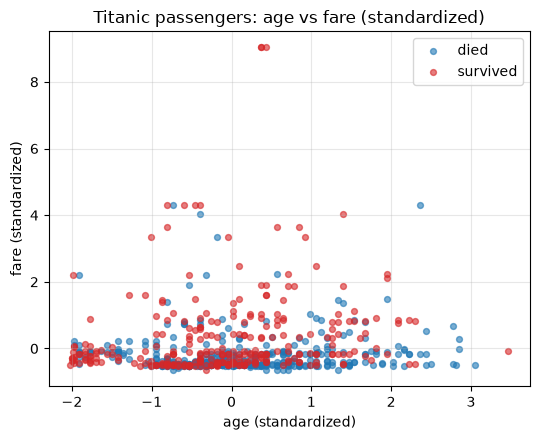

In [2]:
# The test problem: real Titanic passengers, described by age and ticket fare only.
# Survival is NOT a straight-line function of those two numbers, which is exactly what
# will expose the limits of a single neuron below.
import pandas as pd
from sklearn.model_selection import train_test_split

# Read the real CSV shipped with this diploma (no internet required).
titanic = pd.read_csv("../../../Course 04/datasets/raw/titanic.csv")
print(f"Raw manifest      : {len(titanic)} passengers")
print(f"Missing 'Age'     : {titanic['Age'].isna().sum()} rows (real gaps in a 1912 record)")

# Keep the two numeric features and the label; drop rows with no recorded age.
data = titanic[["Age", "Fare", "Survived"]].dropna()
X_raw = data[["Age", "Fare"]].to_numpy(dtype="float32")
y = data["Survived"].to_numpy()

# Standardize both features (mean 0, std 1). WHY: fare runs from 0 to 512 while age runs
# from 0 to 80 — without rescaling, fare would dominate every gradient step.
X = ((X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)).astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=200, random_state=42, stratify=y)

print(f"\nUsable samples: {len(X)}  (2 features each: standardized age, standardized fare)")
print(f"Training set  : {len(X_train)} samples")
print(f"Test set      : {len(X_test)} samples")
print(f"Class balance : {np.bincount(y)} (died, survived)")
print(f"Always-predict-'died' baseline on the test set: {(y_test == 0).mean():.3f}")

# Plot the two classes so the messy, overlapping structure of the real data is visible.
plt.figure(figsize=(5.5, 4.5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="tab:blue", s=18, alpha=0.6, label="died")
plt.scatter(X[y == 1, 0], X[y == 1, 1], c="tab:red", s=18, alpha=0.6, label="survived")
plt.title("Titanic passengers: age vs fare (standardized)")
plt.xlabel("age (standardized)")
plt.ylabel("fare (standardized)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. The Experiment: Same Neuron, Three Activations

Our model is as small as a neural network can get: **one `Dense(1)` layer** — a
single neuron with 2 weights and 1 bias (3 trainable parameters). We train it three
times, and between runs we change **only the activation function**. Everything else
is fixed:

- same real data and same train/test split (514 train / 200 test passengers),
- same loss (mean squared error against the 0/1 labels — it works for all three
  output ranges, so the comparison stays fair),
- same optimizer, epochs, and random seed.

The predicted class is `1` when the neuron's output is above 0.5, else `0`.

In [3]:
# The experiment: train an identical single-neuron model three times, changing ONLY
# the activation function — any performance difference is then due to the activation alone.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

ACTIVATIONS = ["sigmoid", "tanh", "relu"]
results = {}

def train_single_neuron(activation):
    keras.utils.set_random_seed(42)   # identical initialization for every run
    model = Sequential([
        Input(shape=(2,)),
        Dense(1, activation=activation),
    ])
    model.compile(optimizer=Adam(learning_rate=0.05), loss="mse")
    model.fit(X_train, y_train, epochs=150, batch_size=32, verbose=0)
    return model

def accuracy(model, X_, y_):
    preds = (model.predict(X_, verbose=0).ravel() > 0.5).astype(int)
    return (preds == y_).mean()

print("Training one single-neuron model per activation (150 epochs each)...\n")
print(f"{'activation':<10} | {'params':>6} | {'train acc':>9} | {'test acc':>8}")
print("-" * 44)
# Train and score one model per activation under identical conditions.
for act in ACTIVATIONS:
    model = train_single_neuron(act)
    tr, te = accuracy(model, X_train, y_train), accuracy(model, X_test, y_test)
    results[act] = {"model": model, "train_acc": tr, "test_acc": te}
    print(f"{act:<10} | {model.count_params():>6} | {tr:>9.3f} | {te:>8.3f}")

Training one single-neuron model per activation (150 epochs each)...

activation | params | train acc | test acc
--------------------------------------------


sigmoid    |      3 |     0.673 |    0.665


tanh       |      3 |     0.656 |    0.670


relu       |      3 |     0.656 |    0.640


## 4. Decision Boundaries — One Figure, Three Activations

Accuracy numbers alone don't show *how* each neuron divides the plane. Below we
color the plane by each model's predicted class and overlay the test points. Watch
the **shape of the border** between the two colored regions in each panel.

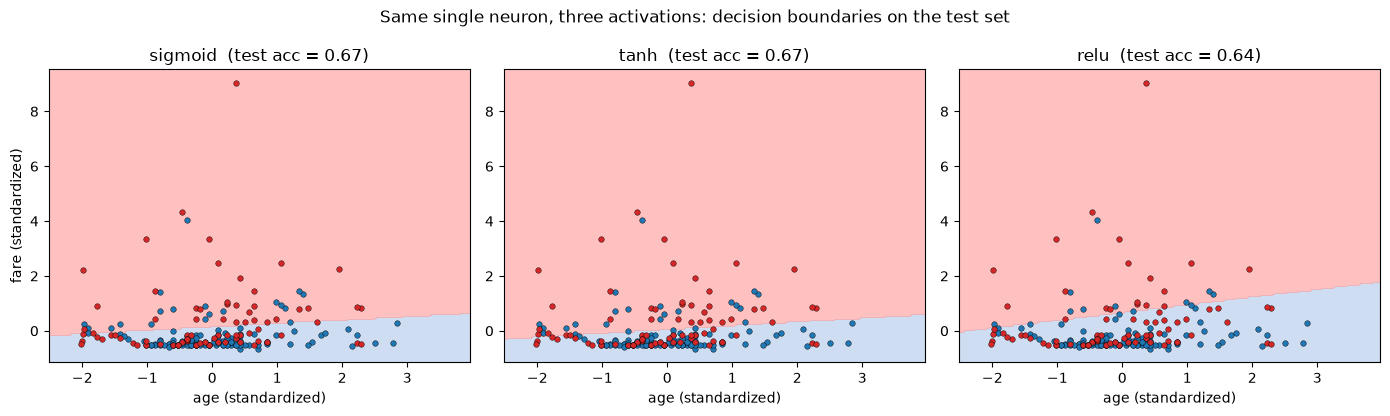

Test accuracies: sigmoid=0.665, tanh=0.670, relu=0.640
Spread between best and worst activation: 0.030

Every panel shows a STRAIGHT-LINE border between the two regions:
a single neuron's boundary is where w1*x1 + w2*x2 + b crosses a fixed
threshold, and a monotonic activation cannot bend that line.


In [4]:
# Visualize each model's decision boundary on a dense grid: all three are straight
# lines, because one neuron computes a single weighted sum no matter the activation.
# Build a grid covering the feature space; classifying every grid point reveals the boundary.
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200),
                     np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, act in zip(axes, ACTIVATIONS):
    zz = (results[act]["model"].predict(grid, verbose=0).ravel() > 0.5)
    zz = zz.astype(int).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5],
                colors=["#aec7e8", "#ff9896"], alpha=0.6)
    ax.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1],
               c="tab:blue", s=16, edgecolors="k", linewidths=0.3)
    ax.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1],
               c="tab:red", s=16, edgecolors="k", linewidths=0.3)
    ax.set_title(f"{act}  (test acc = {results[act]['test_acc']:.2f})")
    ax.set_xlabel("age (standardized)")
axes[0].set_ylabel("fare (standardized)")
plt.suptitle("Same single neuron, three activations: decision boundaries on the test set")
plt.tight_layout()
plt.show()

accs = [results[a]["test_acc"] for a in ACTIVATIONS]
print(f"Test accuracies: " +
      ", ".join(f"{a}={results[a]['test_acc']:.3f}" for a in ACTIVATIONS))
print(f"Spread between best and worst activation: {max(accs) - min(accs):.3f}")
print("\nEvery panel shows a STRAIGHT-LINE border between the two regions:")
print("a single neuron's boundary is where w1*x1 + w2*x2 + b crosses a fixed")
print("threshold, and a monotonic activation cannot bend that line.")

---

## ✅ Summary

**What the outputs actually show:**

- All three activations land within **three percentage points** of each other:
  test accuracy 0.665 (sigmoid), 0.670 (tanh), 0.640 (relu).
- All three scores sit just above the **0.595** you would get by predicting "died" for
  every passenger. Age and fare alone carry only a little of the survival signal — the
  strongest predictor on the Titanic, `Sex`, is not among our two features.
- All three decision boundaries are **straight lines**. Changing the activation
  tilted the line slightly, but never bent it around the overlapping clouds — so roughly
  the same passengers get misclassified in every panel.

**Why:** a single neuron computes one linear score `z = w·x + b`, and classifying by
thresholding a *monotonic* activation of `z` is the same as thresholding `z` itself.
So the activation changes the output's *range* and the training dynamics — but with
one neuron, the boundary stays linear no matter which activation you pick.

**The takeaway:** this real problem needs a *curved* boundary. Survival by age is
**non-monotonic** in the manifest — 58% for passengers aged 12 and under, about 39% right
through the 12-60 range, then 23% for those over 60 — while survival climbs steadily with
fare (20% in the cheapest quarter of tickets, 62% in the most expensive). A single straight
line cannot cut "children survive, the elderly do not, and the middle is flat" out of the
plane, and no activation choice can give a lone neuron that shape. The fix is **more neurons in hidden layers**,
where activations become essential: stacking purely linear layers would collapse
back into one straight line. That is exactly where the next notebook picks up.

---

## 💬 Discuss

Argue from the printed numbers: test accuracy **sigmoid 0.665, tanh 0.670, relu
0.640**, spread **0.030**, against an always-predict-"died" baseline of **0.595**
on 200 held-out passengers.

1. The best and worst activation differ by 3 percentage points — **6 passengers
   out of 200**. With one training run each and no repeated seeds, is "tanh is
   best on this data" a finding? Say exactly what experiment you would run to turn
   that spread into a claim, and how many runs you would want.
2. All three beat the 0.595 baseline, by between 4.5 and 7.5 points. A hospital
   or an insurer would call that a small edge over "assume the common case".
   **Would you deploy any of these three models?** If not, is the fix a better
   activation, a bigger network, or different features? Point at the evidence in
   the three decision-boundary panels.
3. The summary notes that survival by age is **non-monotonic** — 58% for children
   under 12, about 39% through the 12-60 range, 23% over 60 — while survival rises
   steadily with fare. One neuron cannot represent the first pattern and can
   represent the second. **Given only these two features, what would you add
   first: a hidden layer, or a hand-built feature such as `is_child`?** Defend the
   cost of each to a client who has to maintain it.


## ⚠️ Where this breaks

**The most important limit is the one this notebook proves.** All three panels
show a **straight-line** boundary. A single neuron computes one weighted sum
`z = w·x + b`, and thresholding a *monotonic* function of `z` at 0.5 is the same
as thresholding `z` — so the activation can tilt the line and change how training
behaves, but it can never bend it. **No activation choice will fix a model that
needs a curved boundary.** The fix is more neurons in hidden layers, and there the
activation becomes essential: stacking purely linear layers collapses back to a
single straight line.

- **The 0.03 spread is within noise.** One run per activation, one seed, one
  split, 200 test passengers. Treat this table as a demonstration of *method* —
  change one thing, hold everything else — not as a ranking of activations.
- **We used MSE on 0/1 labels to keep the comparison fair** across three different
  output ranges. That is not what you would do in practice: for binary
  classification, use a sigmoid output with binary cross-entropy. The fair
  comparison and the good model are not the same configuration here, and it is
  worth knowing when a teaching choice costs accuracy.
- **ReLU on the *output* of a classifier is a mistake we made deliberately.**
  Its range is [0, ∞), so thresholding at 0.5 is arbitrary and the output is not a
  probability. ReLU belongs in hidden layers; outputs want sigmoid (binary) or
  softmax (multi-class).
- **Dying ReLU is real.** Units pushed into the negative region have exactly zero
  gradient and never recover. **Cheaper alternative:** Leaky ReLU or ELU, which
  keep a small negative slope, or simply a smaller learning rate.
- **Sigmoid and tanh saturate.** With deep stacks the gradient is multiplied by a
  near-zero slope at every layer and the early layers stop learning. This is the
  historical reason deep networks were hard to train before ReLU, careful
  initialisation and normalisation layers.
- **Two features cannot carry this problem.** The strongest predictor of Titanic
  survival is `Sex`, and it is not in our feature set. No activation, and no
  architecture, recovers information that was never given to the model.


## 📚 References

1. McCulloch, W. S., & Pitts, W. (1943). *A Logical Calculus of the Ideas Immanent in Nervous Activity*. Bulletin of Mathematical Biophysics, 5, 115–133.
2. Nair, V., & Hinton, G. E. (2010). *Rectified Linear Units Improve Restricted Boltzmann Machines* (ReLU). ICML.
3. Dubey, S. R., Singh, S. K., & Chaudhuri, B. B. (2022). *Activation Functions in Deep Learning: A Comprehensive Survey and Benchmark*. Neurocomputing. <https://arxiv.org/abs/2109.14545>